# SEO Article Generator — Demo

A backend service that takes a topic and returns a fully structured, SEO-validated article by analysing the top 10 Google search results and generating content through a multi-stage LLM pipeline.

**Stack:** FastAPI · LangGraph · Claude Sonnet · SerpAPI · SQLite

---
## 1. Project Structure

In [49]:
import os

DESCRIPTIONS = {
    "main.py":             "FastAPI app — endpoints, lifespan, background job runner",
    "graph":               "LangGraph pipeline (builder + 6 node files)",
    "builder.py":          "Wires nodes into a compiled StateGraph",
    "state.py":            "ArticleState TypedDict shared across all nodes",
    "nodes":               "One file per pipeline stage",
    "models":              "Pydantic schemas for every layer (inputs → SERP → outline → article)",
    "prompts":             "System + user prompt builders, kept separate from node logic",
    "services":            "SerpAPI wrapper + deterministic mock for testing",
    "db":                  "SQLite job tracking — status, stage, result JSON",
    "tests":               "10 SEO constraint tests run against a fixture",
}

SKIP = {"__pycache__", ".venv", "aiseo_env", ".git",
        "checkpoints.db", "jobs.db", ".env", "requirements.txt",
        "__init__.py", ".gitignore", "fixtures"}

def _tree(root, prefix="", depth=0, max_depth=2):
    if depth > max_depth:
        return
    try:
        items = sorted(
            [i for i in os.listdir(root) if i not in SKIP and not i.endswith(".pyc")],
            key=lambda x: (os.path.isfile(os.path.join(root, x)), x)
        )
    except PermissionError:
        return
    for idx, name in enumerate(items):
        path = os.path.join(root, name)
        connector = "└── " if idx == len(items) - 1 else "├── "
        desc = DESCRIPTIONS.get(name, "")
        suffix = f"  ← {desc}" if desc else ""
        print(f"{prefix}{connector}{name}{suffix}")
        if os.path.isdir(path):
            extension = "    " if idx == len(items) - 1 else "│   "
            _tree(path, prefix + extension, depth + 1, max_depth)

seo_agent_path = os.path.join(os.path.dirname(os.path.abspath("__file__")))
print("ROOT/")
_tree(seo_agent_path)

ROOT/
├── db  ← SQLite job tracking — status, stage, result JSON
│   └── jobs.py
├── graph  ← LangGraph pipeline (builder + 6 node files)
│   ├── nodes  ← One file per pipeline stage
│   │   ├── analyze_serp.py
│   │   ├── build_outline.py
│   │   ├── generate_sections.py
│   │   ├── postprocess.py
│   │   ├── serp_fetch.py
│   │   └── validate_output.py
│   ├── builder.py  ← Wires nodes into a compiled StateGraph
│   └── state.py  ← ArticleState TypedDict shared across all nodes
├── models  ← Pydantic schemas for every layer (inputs → SERP → outline → article)
│   ├── article.py
│   ├── inputs.py
│   ├── outline.py
│   └── serp.py
├── prompts  ← System + user prompt builders, kept separate from node logic
│   ├── analyze_serp.py
│   ├── build_outline.py
│   └── generate_section.py
├── seo_agent
├── services  ← SerpAPI wrapper + deterministic mock for testing
│   └── serp_client.py
├── tests  ← 10 SEO constraint tests run against a fixture
│   └── test_seo_constraints.py
├── .env.examp

---
## 2. Pipeline Architecture

The article is generated through a 6-node LangGraph pipeline. Each node reads from a shared `ArticleState` TypedDict and writes back a partial update — LangGraph merges updates immutably between steps and checkpoints state to SQLite after every node.

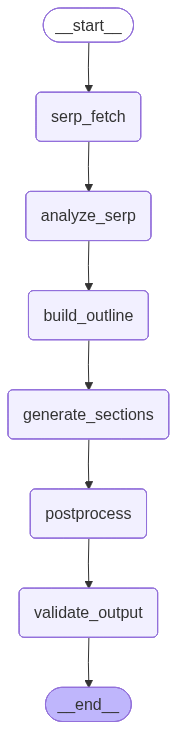

In [51]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), "seo_agent"))

from langgraph.checkpoint.memory import MemorySaver
from graph.builder import build_graph
from IPython.display import Image

graph = build_graph(MemorySaver())
Image(graph.get_graph().draw_mermaid_png())

---
## 3. Live Run

> **Pre-requisite:** The API server must be running before executing these cells.
> ```bash
> cd seo_agent
> uvicorn main:app --reload --port 8000
> ```

Jobs are submitted asynchronously — the API returns a `thread_id` immediately (`202 Accepted`) and the pipeline runs in the background. We poll `/jobs/{thread_id}` to watch the stage progress.

In [52]:
import requests
import time

BASE_URL = "http://localhost:8000"

In [53]:
payload = {
    "topic": "best productivity tools for remote teams",
    "target_word_count": 1500,
    "language": "en",
    "use_mock": False   # set True to skip SerpAPI and use built-in mock data
}

resp = requests.post(f"{BASE_URL}/jobs", json=payload)
resp.raise_for_status()
job = resp.json()

thread_id = job["thread_id"]
print(f"✓ Job submitted")
print(f"  thread_id : {thread_id}")
print(f"  status    : {job['status']}")

✓ Job submitted
  thread_id : 556071e6-4011-4b4e-94af-5856099ca390
  status    : pending


In [55]:
STAGES = [
    "serp_fetch",
    "analyze_serp",
    "build_outline",
    "generate_sections",
    "postprocess",
    "validate_output",
]

seen_stages = set()
stage_start = time.time()
poll_count = 0
print("Polling — stages will appear as they complete:\n")

while True:
    resp = requests.get(f"{BASE_URL}/jobs/{thread_id}")
    resp.raise_for_status()
    data = resp.json()
    poll_count += 1

    stage = data.get("execution_stage")
    job_status = data["status"]

    if stage and stage not in seen_stages:
        idx = STAGES.index(stage) + 1 if stage in STAGES else "?"
        elapsed = time.time() - stage_start
        print(f"  [{idx}/{len(STAGES)}] ✓ {stage:<20}  {elapsed:5.1f}s  ({poll_count} poll{'s' if poll_count != 1 else ''})")
        seen_stages.add(stage)
        stage_start = time.time()
        poll_count = 0

    if job_status in ("completed", "failed"):
        print(f"\nJob {job_status.upper()}")
        if data.get("error_message"):
            print(f"Error: {data['error_message']}")
        break

    time.sleep(3)

Polling — stages will appear as they complete:

  [6/6] ✓ validate_output         2.1s  (1 poll)

Job FAILED
Error: Missing article output or outline for validation


> Each node completion fires an `on_chain_end` event via `astream_events()`, which updates the job stage in `jobs.db`. The poll interval is 3 seconds.

In [ ]:
resp = requests.get(f"{BASE_URL}/jobs/{thread_id}/result")
resp.raise_for_status()
result = resp.json()

print(f"Result fetched — {len(result)} top-level keys")
print(list(result.keys()))

---
## 4. Results Walkthrough

The response is a single `ArticleOutput` object with three logical groups:

| Group | Keys |
|---|---|
| **Article Content** | `h1`, `meta_title`, `meta_description`, `body_markdown`, `word_count` |
| **SEO Intelligence** | `keyword_analysis`, `internal_links`, `external_references`, `faq` |
| **Quality Gate** | `validation_results` |

### 4.1 Article Content

In [ ]:
print("H1")
print(f"  {result['h1']}")
print()
print("Meta Title")
print(f"  {result['meta_title']}  ({len(result['meta_title'])} chars)")
print()
print("Meta Description")
print(f"  {result['meta_description']}  ({len(result['meta_description'])} chars)")
print()
print(f"Word Count:  {result['word_count']}  (target: 1500)")

In [ ]:
# Show the opening of the article body
preview = result["body_markdown"][:800]
print(preview)
print("\n[... article continues ...]")

### 4.2 SEO Intelligence

In [ ]:
ka = result["keyword_analysis"]

print("── Keyword Analysis ─────────────────────────────────────────────────")
print(f"  Primary keyword : '{ka['primary_keyword']}'")
print(f"  Occurrences     : {ka['primary_keyword_count']}")
print(f"  Density         : {ka['keyword_density']:.2%}")
print(f"  Secondary KWs   : {len(ka['secondary_keywords'])} tracked")
for kw in ka["secondary_keywords"][:4]:
    sections = ", ".join(kw["sections_present"][:2]) or "—"
    print(f"    · '{kw['keyword']}' — {kw['count']} occurrences  |  in: {sections}")
print()

print("── Internal Links ───────────────────────────────────────────────────")
for link in result["internal_links"]:
    print(f"  · \"{link['anchor_text']}\"")
    print(f"    → target: {link['suggested_target_topic']}")
print()

print("── External References ──────────────────────────────────────────────")
for ref in result["external_references"]:
    print(f"  · {ref['source_name']}")
    print(f"    section: {ref['placement_section']}")
print()

print("── FAQ ──────────────────────────────────────────────────────────────")
for item in result["faq"]:
    print(f"  Q: {item['question']}")
    print(f"  A: {item['answer'][:120]}...")
    print()

### 4.3 Validation Layer

10 programmatic SEO checks — no LLM involved. Each check is deterministic: regex, character counts, arithmetic. The overall score is the percentage of checks passed.

In [ ]:
vr = result["validation_results"]
score = vr["overall_score"]
overall_icon = "✅" if vr["passed"] else "⚠️"

print(f"Overall Score: {score}/100  {overall_icon}")
print()
print(f"{'Check':<38}  {'Result':<6}  Detail")
print("─" * 90)
for check in vr["checks"]:
    icon = "✅" if check["passed"] else "❌"
    print(f"{check['check_name']:<38}  {icon:<6}  {check['detail']}")

> The output is a single Pydantic-validated `ArticleOutput` object — structured, schema-validated, and ready to hand off to a CMS or post-processing step.